![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_4/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Analizando el Delito en Chicago

En este caso-taller vamos a utilizar datos geográficos y estimación de densidad de kernel para analizar delitos en Chicago. Esta ciudad es muy famosa no sólo por haber sido el hogar del mafioso Al Capone, sino también por sus altas tasas de delitos.

Para este taller obtuve datos del portal de la [ciudad de Chicago](https://www.chicago.gov/city/en/dataset/crime.html). La base de datos fue traducida y modificada para nuestras necesidades. Esta contiene todos los homicidios y robos que sucedieron entre el 1 de junio y el 31 de agosto de 2019.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

#### 1.1. Delitos

En la carpeta `data` se encuentra el archivo `Chicago_delitos_verano_2019.csv` cargue estos datos en su *cuaderno*. Describa brevemente el contenido de la base.

In [1]:
#Configuración del ambiente
import os
import pandas as pd
import numpy as np
!pip install geopandas -q
import geopandas as gpd
!git clone https://github.com/camto-24/taller_4_Aprendizaje_no_supervisado.git
os.listdir("/content")
os.listdir("/content/taller_4_Aprendizaje_no_supervisado")

#Cargamos la base
ruta = "/content/taller_4_Aprendizaje_no_supervisado/data/Chicago_delitos_verano_2019.csv"
delitos = pd.read_csv(ruta, low_memory=False)
delitos.head()

Cloning into 'taller_4_Aprendizaje_no_supervisado'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 18), reused 15 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.31 MiB | 6.07 MiB/s, done.
Resolving deltas: 100% (18/18), done.


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256


In [3]:
# Tamaño de la base
print("Número de filas y columnas:", delitos.shape)

# Nombres de las columnas
print("\nColumnas disponibles:")
print(delitos.columns)

# Información general
print("\nInformación general:")
delitos.info()

# Valores nulos por columna
delitos.isnull().sum()

# Tipos de delitos más frecuentes
delitos["tipo_crimen"].value_counts().head(10)

# Lugares donde ocurren más delitos
delitos["nro_area_comunitaria"].value_counts().head(10)

#Tratamiento de la fecha
delitos["fecha"] = pd.to_datetime(delitos["fecha"], errors="coerce")
delitos["fecha"].min(), delitos["fecha"].max()

Número de filas y columnas: (17747, 5)

Columnas disponibles:
Index(['fecha', 'tipo_crimen', 'nro_area_comunitaria', 'lat', 'lon'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17747 entries, 0 to 17746
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 17747 non-null  object 
 1   tipo_crimen           17747 non-null  object 
 2   nro_area_comunitaria  17747 non-null  int64  
 3   lat                   17747 non-null  float64
 4   lon                   17747 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 693.4+ KB


(Timestamp('2019-06-01 05:00:00+0000', tz='UTC'),
 Timestamp('2019-09-01 04:48:00+0000', tz='UTC'))

La base de datos contiene 17.747 registros y 5 columnas. Cada fila representa un delito reportado en Chicago durante el periodo de análisis e incluye la fecha del delito, el tipo de crimen, el número del área comunitaria, y las coordenadas geográficas de latitud y longitud donde ocurrió el evento. Estas dos últimas variables son fundamentales para el análisis espacial, porque permiten ubicar cada delito en el mapa y construir posteriormente una estimación de densidad de kernel.

En la revisión inicial se encontró que la base no tiene valores nulos en ninguna de sus variables, lo cual facilita el análisis porque no es necesario eliminar registros por falta de información. También se observó que el tipo de delito más frecuente es el robo, con 17.603 ocurrencias, lo que representa casi la totalidad de los registros. Esto indica que la base está altamente concentrada en este tipo de crimen, por lo que el análisis espacial reflejará principalmente la distribución geográfica de los robos.

En cuanto a la variable de área comunitaria, el área con mayor número de delitos es la 32, seguida por las áreas 8 y 28. Esto sugiere que existen zonas específicas de la ciudad donde los reportes se concentran con mayor intensidad. Por esta razón, el uso de estimaciones de densidad de kernel resulta útil, ya que permite identificar visualmente los puntos calientes o zonas de mayor concentración delictiva en Chicago.



#### 1.2. Barrios de Chicago

También en la carpeta `data` se encuentran los archivos con los polígonos de las áreas comunitarias en un archivo comprimido llamado `Areas_comunitarias_Chicago.zip`. Genere un mapa interactivo con un popup con el nombre del area comunitaria.

In [2]:
# Configuración del entorno
import glob
import matplotlib.pyplot as plt
ruta_areas = "/content/taller_4_Aprendizaje_no_supervisado/data/Areas_comunitarias_Chicago.zip"

#Cargamos los datos
areas = gpd.read_file(f"zip://{ruta_areas}")
areas.head()


,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len,geometry
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


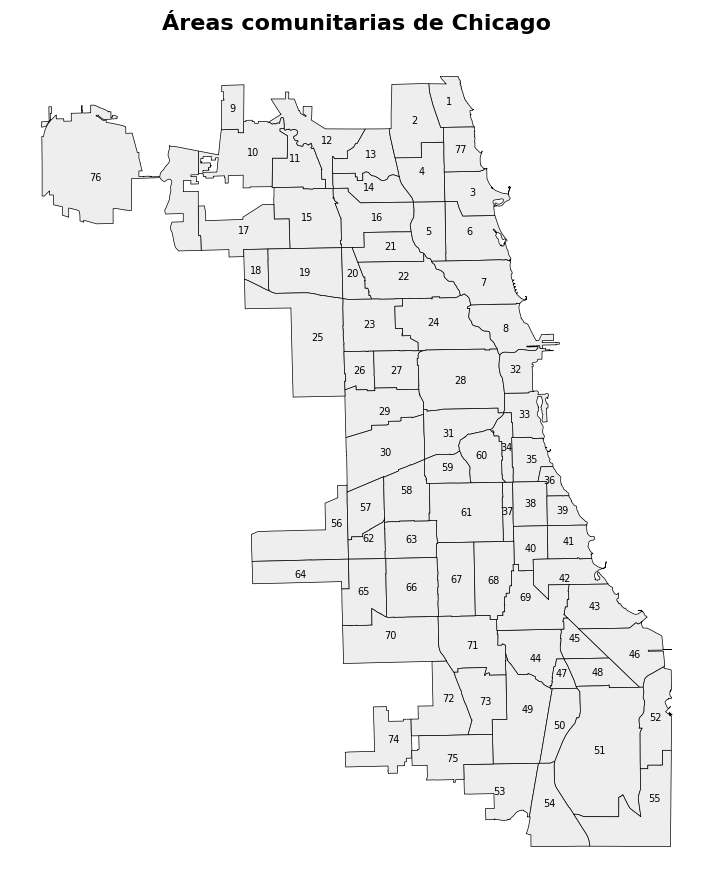

In [4]:
#Graficamos las áreas
fig, ax = plt.subplots(figsize=(11, 11))

areas.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="black",
    linewidth=0.5
)

# Agregar etiquetas en el centro de cada polígono
for idx, row in areas.iterrows():
    punto = row.geometry.representative_point()
    ax.text(
        punto.x,
        punto.y,
        str(row["area_numbe"]),
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title(
    "Áreas comunitarias de Chicago",
    fontsize=16,
    fontweight="bold"
)

ax.axis("off")

plt.show()

Además de la base de delitos, se cargó una representación geográfica con los polígonos de las áreas comunitarias de Chicago. Esta base tiene 77 filas y 10 columnas, donde cada fila corresponde a una de las áreas comunitarias de la ciudad. Dentro de sus variables se encuentra el número del área, el ID del área, el nombre de la comunidad y la columna geometry, que contiene los polígonos que delimitan espacialmente cada zona.

También se revisó el sistema de coordenadas de la capa geográfica, el cual corresponde a WGS84, un sistema de referencia geográfico en dos dimensiones. Esto significa que las ubicaciones están expresadas en coordenadas de latitud y longitud, lo cual es compatible con la base de delitos, que también contiene estas variables. Esta verificación es importante porque, para realizar análisis espaciales correctamente, tanto los puntos de delitos como los polígonos de las áreas comunitarias deben estar en el mismo sistema de coordenadas.

La visualización inicial de los polígonos permite observar la división territorial de Chicago en sus 77 áreas comunitarias. Esta capa será utilizada como base espacial para ubicar los delitos dentro de la ciudad.

### 2.   Análisis distribución del crimen por barrios

#### 2.1.  Genere una tabla descriptiva donde se muestra el número total de delitos, el número total de robos y el número total de homicidios, y como porcentaje de total por barrios. La tabla debe contener ademas una fila final donde se muestre el total para la ciudad. Describa los resultados que obtiene.


In [5]:
#Creamos una base exclusivamente para hacer la tabla
delitos_tabla = delitos.copy()
areas_tabla = areas.copy()

#Creamos variables indicadoras
delitos_tabla["es_robo"] = (delitos["tipo_crimen"] == "robo").astype(int)
delitos_tabla["es_homicidio"] = (delitos_tabla["tipo_crimen"] == "homicidio").astype(int)

#Tabla de delitos
delitos_tabla[["es_robo", "es_homicidio"]].sum()

,0
es_robo,17603
es_homicidio,144


In [6]:
#Total de delitos
total_delitos = delitos_tabla["es_robo"].sum() + delitos_tabla["es_homicidio"].sum()
total_delitos

np.int64(17747)

In [7]:
#Agrupación por área
tabla_barrios = (
    delitos_tabla
    .groupby("nro_area_comunitaria")
    .agg(
        total_delitos=("tipo_crimen", "count"),
        total_robos=("es_robo", "sum"),
        total_homicidios=("es_homicidio", "sum")
    )
    .reset_index()
)

tabla_barrios.head()

,nro_area_comunitaria,total_delitos,total_robos,total_homicidios
0,1,377,375,2
1,2,280,280,0
2,3,266,266,0
3,4,169,169,0
4,5,99,99,0


In [8]:
#Cálculo del porcentaje de cada delito por barrio
tabla_barrios["pct_robos"] = (
    tabla_barrios["total_robos"] / tabla_barrios["total_delitos"] * 100
)

tabla_barrios["pct_homicidios"] = (
    tabla_barrios["total_homicidios"] / tabla_barrios["total_delitos"] * 100
)

#Se redondea el valor
tabla_barrios["pct_robos"] = tabla_barrios["pct_robos"].round(2)
tabla_barrios["pct_homicidios"] = tabla_barrios["pct_homicidios"].round(2)

#Tabla de resultados
tabla_barrios.head(10)

,nro_area_comunitaria,total_delitos,total_robos,total_homicidios,pct_robos,pct_homicidios
0,1,377,375,2,99.47,0.53
1,2,280,280,0,100.00,0.00
2,3,266,266,0,100.00,0.00
3,4,169,169,0,100.00,0.00
4,5,99,99,0,100.00,0.00
5,6,763,762,1,99.87,0.13
6,7,525,522,3,99.43,0.57
7,8,1559,1559,0,100.00,0.00
8,9,19,19,0,100.00,0.00
9,10,98,98,0,100.00,0.00


In [9]:
tabla_barrios.shape

(77, 6)

Para analizar la distribución del crimen por barrios, primero se creó una variable indicadora para identificar los casos de robo y otra para identificar los casos de homicidio. Estas variables toman el valor de 1 cuando el registro corresponde a ese delito y 0 en caso contrario. Luego, se sumaron ambas variables para obtener el total de delitos considerados en la base.

A partir de esto se encontró que, durante el periodo de análisis en Chicago, se registraron 17.747 delitos en total. De estos, 17.603 corresponden a robos, lo que convierte al robo en el crimen más común en todos los barrios analizados. En contraste, los homicidios suman 144 casos, una cifra mucho menor frente al número de robos.

Posteriormente, al agrupar la información por barrio, se calcularon los porcentajes que representan los robos y los homicidios dentro del total de delitos de cada área comunitaria. Los resultados muestran que el delito con mayor peso porcentual en los barrios es el robo, lo cual era esperable dado que este tipo de crimen concentra casi la totalidad de los registros de la base. Por su parte, el homicidio tiene una participación mucho menor en comparación con el robo en todos los barrios.

En conclusión, la distribución del crimen en esta base está fuertemente concentrada en robos.

#### 2.2. Genere una gráfica de dispersión entre el total de homicidios y robos por barrios. Incluya en la gráfica la recta de regresión que mejor ajusta a esos datos. Describa los resultados que obtiene.

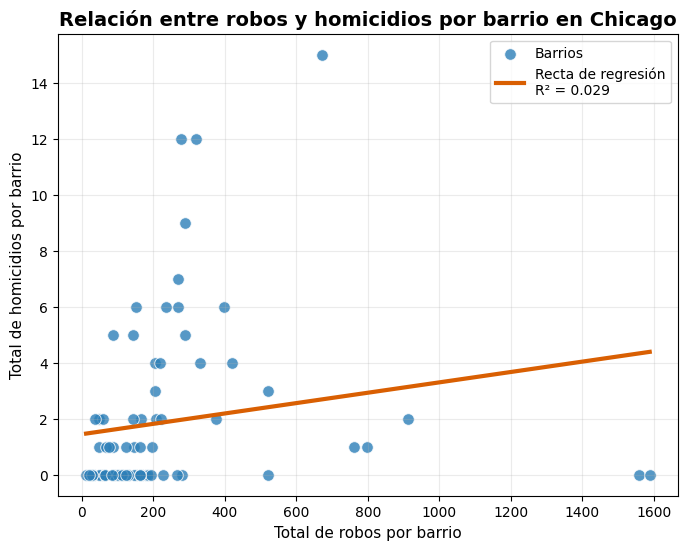

In [10]:
# Variables para la gráfica
x = tabla_barrios["total_robos"]
y = tabla_barrios["total_homicidios"]

# Ajustar recta de regresión
pendiente, intercepto = np.polyfit(x, y, 1)

# Valores predichos
y_pred = pendiente * x + intercepto

# Calcular R cuadrado
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Línea de regresión ordenada
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = pendiente * x_linea + intercepto

# Gráfica
plt.figure(figsize=(8, 6))

# Puntos
plt.scatter(
    x,
    y,
    color="#2C7FB8",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.8,
    s=70,
    label="Barrios"
)

# Recta de regresión
plt.plot(
    x_linea,
    y_linea,
    color="#D95F02",
    linewidth=3,
    label=f"Recta de regresión\nR² = {r2:.3f}"
)

# Títulos y etiquetas
plt.title(
    "Relación entre robos y homicidios por barrio en Chicago",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total de robos por barrio", fontsize=11)
plt.ylabel("Total de homicidios por barrio", fontsize=11)

plt.grid(alpha=0.25)
plt.legend()
plt.show()


La gráfica de dispersión compara el número total de robos y homicidios por barrio en Chicago. Cada punto representa un barrio, donde el eje horizontal muestra el total de robos y el eje vertical muestra el total de homicidios. Además, se incluyó una recta de regresión para observar la tendencia general entre ambas variables.

En principio, no se observa una relación clara entre robos y homicidios. Aunque la recta de regresión tiene una pendiente ligeramente positiva, la mayoría de los puntos están bastante dispersos y no siguen un patrón fuerte. Esto significa que los barrios con más robos no necesariamente son también los barrios con más homicidios.

El valor de R² = 0.029 confirma esta relación débil, ya que indica que el total de robos explica apenas cerca del 2,9% de la variación en los homicidios por barrio. En otras palabras, el número de robos no parece ser un buen predictor del número de homicidios en esta base.

También se observan algunos casos particulares. Hay barrios con muchos robos y casi ningún homicidio, mientras que otros barrios con niveles medios de robos presentan más homicidios. Esto refuerza la idea de que ambos delitos pueden tener distribuciones espaciales distintas y que el análisis de concentración geográfica debe revisarse por separado para cada tipo de crimen.

### 3. Distribución espacial del delito

#### 3.1 Distribución respecto al centro de la ciudad

Tomando como centro de la ciudad las coordenadas (-87.627800, 41.881998), estime funciones de densidad que muestren gráficamente el gradiente del total de robos, y homicidios, como función de la distancia al centro de la ciudad. Explique cómo midió las distancias incluyendo que medida de distancia utilizó. Para elegir el ancho de banda y la función de kernel más apropiados utilice validación cruzada usando todas las opciones posibles de kernel. Describa los resultados que obtiene.

In [17]:
# Librerías
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from geopy.distance import geodesic
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Centro de Chicago y cálculo de distancias

# Coordenadas centro de Chicago
centro = (41.881998, -87.627800)

# Lista para guardar distancias
distancias = []

# Calcular distancia geodésica para cada delito
for i in range(delitos.shape[0]):

    punto = (
        delitos.iloc[i]["lat"],
        delitos.iloc[i]["lon"]
    )

    distancia = geodesic(
        centro,
        punto
    ).km

    distancias.append(distancia)

# Guardar variable
delitos["distancia_centro"] = distancias

# Verificar resultados
delitos[["tipo_crimen", "distancia_centro"]].head()

,tipo_crimen,distancia_centro
0,homicidio,8.553361
1,homicidio,14.405275
2,homicidio,10.215364
3,homicidio,10.529419
4,homicidio,8.589379


In [18]:
### Separar robos y homicidios

# Distancias de robos
robos = delitos[
    delitos["tipo_crimen"] == "robo"
]["distancia_centro"]

# Distancias de homicidios
homicidios = delitos[
    delitos["tipo_crimen"] == "homicidio"
]["distancia_centro"]

# Tamaños
print("Número de robos:", len(robos))
print("Número de homicidios:", len(homicidios))

Número de robos: 17603
Número de homicidios: 144


In [19]:
### Validación cruzada para robos

# Convertir a arreglo
vals_robos = robos.to_numpy().reshape(-1, 1)

# Bandwidths
bandwidths = 10 ** np.linspace(-2, 0, 10)

# Parámetros
grid = {
    "bandwidth": bandwidths,
    "kernel": [
        "gaussian",
        "epanechnikov",
        "tophat",
        "linear"
    ]
}

# Validación cruzada
gridCV_robos = GridSearchCV(
    KernelDensity(),
    param_grid=grid,
    cv=3
)

gridCV_robos.fit(vals_robos)

# Mejores parámetros
print("Mejores parámetros robos:")
print(gridCV_robos.best_params_)

Mejores parámetros robos:
{'bandwidth': np.float64(0.016681005372000592), 'kernel': 'gaussian'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-17608.41434128            -inf            -inf            -inf
 -17523.60043207            -inf            -inf            -inf
 -17584.23059844            -inf            -inf            -inf
 -17691.08005776            -inf            -inf            -inf
 -17770.12361277            -inf            -inf            -inf
 -17812.1160056             -inf            -inf            -inf
 -17853.35480915 -17813.26364151 -17851.67229564 -17773.37788694
 -17910.49694724 -17838.24159037 -17874.54006735 -17813.55638398
 -17994.88321048 -17889.22446307 -17929.12988164 -17865.53016845
 -18136.9206769  -17957.05129356 -18020.32854706 -17930.2922389 ]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1119: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, wei

In [20]:
### Validación cruzada para homicidios

# Convertir a arreglo
vals_homicidios = homicidios.to_numpy().reshape(-1, 1)

# Validación cruzada
gridCV_homicidios = GridSearchCV(
    KernelDensity(),
    param_grid=grid,
    cv=3
)

gridCV_homicidios.fit(vals_homicidios)

# Mejores parámetros
print("Mejores parámetros homicidios:")
print(gridCV_homicidios.best_params_)

Mejores parámetros homicidios:
{'bandwidth': np.float64(1.0), 'kernel': 'tophat'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-5308.02542873           -inf           -inf           -inf
 -1956.69642092           -inf           -inf           -inf
  -765.64937354           -inf           -inf           -inf
  -348.48200167           -inf           -inf           -inf
  -205.30727318           -inf           -inf           -inf
  -157.45915084           -inf           -inf           -inf
  -142.31092919           -inf           -inf           -inf
  -137.93178253           -inf           -inf           -inf
  -136.90489872           -inf           -inf           -inf
  -137.25792541  -137.03435013  -136.75525943  -137.1974471 ]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1119: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


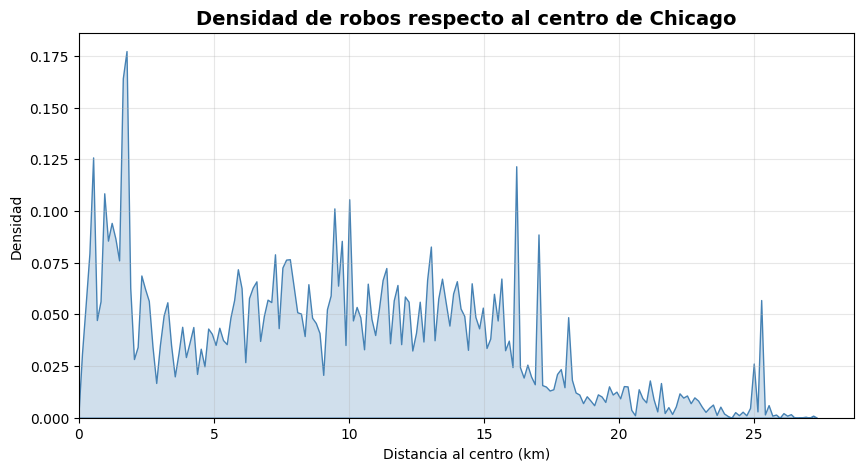

In [23]:
### KDE para robos

# Crear figura y definir tamaño
plt.figure(figsize=(10,5))

# Estimar y graficar la densidad KDE
sns.kdeplot(
    robos,
    fill=True,
    bw_adjust=gridCV_robos.best_params_["bandwidth"],
    color="steelblue"
)

# Título de la gráfica
plt.title(
    "Densidad de robos respecto al centro de Chicago",
    fontsize=14,
    fontweight="bold"
)

## Etiqueta del eje X y Y
plt.xlabel("Distancia al centro (km)")
plt.ylabel("Densidad")

## Ajustar límite inferior del eje X en 0
plt.xlim(0, None)
plt.grid(alpha=0.3)

## Mostrar gráfica
plt.show()

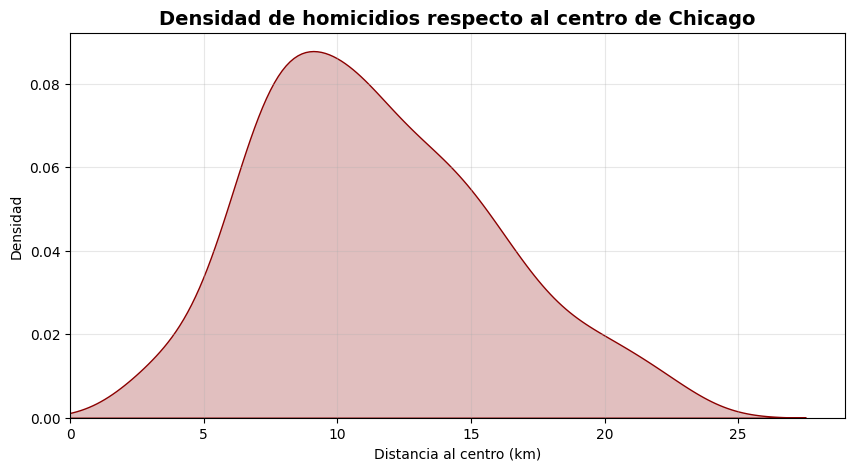

In [22]:
## KDE homicidios

# Crear figura y definir tamaño
plt.figure(figsize=(10,5))

# Estimar y graficar la densidad KDE
sns.kdeplot(
    homicidios,
    fill=True,
    bw_adjust=gridCV_homicidios.best_params_["bandwidth"],
    color="darkred"
)

# Título de la gráfica
plt.title(
    "Densidad de homicidios respecto al centro de Chicago",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Distancia al centro (km)")
plt.ylabel("Densidad")

plt.xlim(0, None)
plt.grid(alpha=0.3)

# Mostrar gráfica
plt.show()

Para analizar la distribución espacial del delito respecto al centro de Chicago, primero se tomó como punto de referencia el centro de la ciudad ubicado en las coordenadas ((-87.627800,\ 41.881998)). A partir de las coordenadas geográficas de cada delito (`lat` y `lon`), se calculó la distancia entre cada observación y el centro utilizando la distancia geodésica mediante la función `geodesic` de la librería `geopy`. Esta medida fue utilizada porque las coordenadas están expresadas en latitud y longitud sobre la superficie terrestre, por lo que la distancia geodésica permite aproximar de manera más adecuada la distancia real en kilómetros entre dos puntos geográficos.

Posteriormente, se separaron los delitos entre robos y homicidios y se estimaron funciones de densidad Kernel (KDE) para analizar cómo se distribuyen espacialmente según su distancia al centro de la ciudad. Para seleccionar el ancho de banda y la función kernel más apropiados, se implementó una validación cruzada con `GridSearchCV`, evaluando distintos valores de bandwidth y las funciones kernel gaussian, epanechnikov, tophat y linear, siguiendo el procedimiento visto en clase.

Los resultados muestran que los robos presentan una mayor concentración en distancias cercanas al centro de Chicago, lo que sugiere una fuerte aglomeración en zonas urbanas centrales y comerciales. Por otro lado, los homicidios presentan una distribución más dispersa y menos concentrada alrededor del centro. Entonces, se concluye que, las estimaciones KDE mostraron que los delitos no se distribuyen igual en la ciudad. Los homicidios se concentran más cerca del centro, mientras que los robos aparecen más dispersos y en zonas más alejadas. Esto indica que cada tipo de delito tiene un patrón espacial diferente y que el método KDE ayuda a identificar las áreas donde los delitos ocurren con mayor frecuencia.


### 3.2 Puntos calientes en la ciudad

Usando `statsmodels` implemente la estimación de densidad bivariada para el total de robos y el total de homicidios. Muestre los resultados usando curvas de nivel en una visualización interactiva. Compare los resultados de estimar usando los anchos de banda: `normal_reference` y `cv_ml`. Explique en que consisten ambas formas de estimar el ancho de banda. Comente sobre los puntos calientes encontrados bajo ambos métodos y su ubicación en la ciudad. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [30]:
# Librerías
import numpy as np
import plotly.graph_objects as go
from statsmodels.nonparametric.kernel_density import KDEMultivariate

### Bases para KDE
# Robos
robos = delitos[
    delitos["tipo_crimen"] == "robo"
].copy()

# Homicidios
homicidios = delitos[
    delitos["tipo_crimen"] == "homicidio"
].copy()

# Coordenadas robos
x_r = robos["lon"].values
y_r = robos["lat"].values

# Coordenadas homicidios
x_h = homicidios["lon"].values
y_h = homicidios["lat"].values

# Malla espacial
xmin = delitos["lon"].min()
xmax = delitos["lon"].max()

ymin = delitos["lat"].min()
ymax = delitos["lat"].max()

xx, yy = np.mgrid[
    xmin:xmax:40j,
    ymin:ymax:40j
]

grid = np.vstack([
    xx.ravel(),
    yy.ravel()
])


In [32]:

# KDE ROBOS

from statsmodels.nonparametric.kernel_density import KDEMultivariate

# normal_reference

kde_robos_nr = KDEMultivariate(
    data=[x_r, y_r],
    var_type='cc',
    bw='normal_reference'
)

dens_robos_nr = kde_robos_nr.pdf(grid)
dens_robos_nr = dens_robos_nr.reshape(xx.shape)

# cv_ml

# Muestra aleatoria para reducir tiempo
robos_sample = robos.sample(
    n=3000,
    random_state=123
)

x_r_sample = robos_sample["lon"].values
y_r_sample = robos_sample["lat"].values

kde_robos_cv = KDEMultivariate(
    data=[x_r_sample, y_r_sample],
    var_type='cc',
    bw='cv_ml'
)

dens_robos_cv = kde_robos_cv.pdf(grid)
dens_robos_cv = dens_robos_cv.reshape(xx.shape)

In [34]:

# KDE HOMICIDIOS

# Coordenadas
x_h = homicidios["lon"].values
y_h = homicidios["lat"].values

# normal_reference

kde_homicidios_nr = KDEMultivariate(
    data=[x_h, y_h],
    var_type='cc',
    bw='normal_reference'
)

dens_homicidios_nr = kde_homicidios_nr.pdf(grid)
dens_homicidios_nr = dens_homicidios_nr.reshape(xx.shape)

# cv_ml

kde_homicidios_cv = KDEMultivariate(
    data=[x_h, y_h],
    var_type='cc',
    bw='cv_ml'
)

dens_homicidios_cv = kde_homicidios_cv.pdf(grid)
dens_homicidios_cv = dens_homicidios_cv.reshape(xx.shape)


In [35]:
# Gráficos

def grafico_kde(xx, yy, densidad, titulo):

    fig = go.Figure()

    fig.add_trace(
        go.Contour(
            x=xx[:,0],
            y=yy[0,:],
            z=densidad.T,
            colorscale='Viridis',
            contours=dict(showlabels=True)
        )
    )

    fig.update_layout(
        title=titulo,
        xaxis_title='Longitud',
        yaxis_title='Latitud',
        template='plotly_white',
        width=800,
        height=600
    )

    fig.show()


grafico_kde(
    xx,
    yy,
    dens_robos_nr,
    "Robos - KDE Bivariado (normal_reference)"
)

grafico_kde(
    xx,
    yy,
    dens_robos_cv,
    "Robos - KDE Bivariado (cv_ml)"
)

grafico_kde(
    xx,
    yy,
    dens_homicidios_nr,
    "Homicidios - KDE Bivariado (normal_reference)"
)

grafico_kde(
    xx,
    yy,
    dens_homicidios_cv,
    "Homicidios - KDE Bivariado (cv_ml)"
)

Para identificar puntos calientes del crimen en Chicago se implementó una estimación de densidad bivariada utilizando la librería `statsmodels` y el método `KDEMultivariate`, siguiendo el procedimiento visto en clase. Primero se separaron los datos de robos y homicidios utilizando las coordenadas geográficas de longitud (`lon`) y latitud (`lat`). Posteriormente, se construyó una grilla bidimensional sobre el espacio geográfico de la ciudad para estimar la densidad espacial de los delitos. La estimación KDE se realizó con dos métodos distintos de selección del ancho de banda: `normal_reference` y `cv_ml`. El método `normal_reference` utiliza una regla teórica basada en la desviación estándar y el tamaño de la muestra para obtener un suavizamiento general de la densidad, mientras que `cv_ml` selecciona el ancho de banda mediante validación cruzada por máxima verosimilitud, buscando el nivel de suavizado que mejor se ajusta a los datos observados. Debido al gran número de observaciones de robos, para el método `cv_ml` se utilizó una muestra aleatoria con el fin de reducir el tiempo de cómputo.

Los resultados muestran diferencias importantes entre ambos métodos. Con `normal_reference`, las superficies de densidad son más suaves y presentan zonas amplias de concentración delictiva, lo que facilita identificar patrones generales en la ciudad. En cambio, con `cv_ml` las curvas de nivel son más irregulares y localizadas, capturando con mayor detalle áreas específicas donde se concentran los delitos. En el caso de los robos, los principales puntos calientes se ubican alrededor de las zonas centrales y comerciales de Chicago, donde existe mayor actividad económica y flujo de personas. Para los homicidios, aunque los eventos son mucho menos frecuentes, se observan concentraciones más focalizadas en ciertas áreas específicas de la ciudad, mostrando una distribución espacial diferente a la de los robos.

En conclusión, la estimación de densidades bivariadas permitió identificar espacialmente las zonas de mayor concentración del crimen en Chicago. Además, la comparación entre `normal_reference` y `cv_ml` mostró que el método de selección del ancho de banda afecta significativamente el nivel de detalle de los puntos calientes detectados. Mientras `normal_reference` ofrece una visión más general y suavizada de la criminalidad, `cv_ml` permite detectar concentraciones más precisas y localizadas. Esto evidencia que distintos tipos de delitos presentan patrones espaciales diferentes dentro de la ciudad.

## 4. Explicando la ubicación del delito

El objetivo de este punto es encontrar posibles correlaciones  entre el crimen y características de la ciudad. Para ello, utilice los datos de OpenStreetMap y explore si existe una correlación entre el porcentaje del área de la comunidad  dedicado a tiendas (`retail`)  y comercios (`commercial`) y el número total de robos y homicidios en esa comunidad. Ofrezca una explicación intuitiva de por qué cree que aparecen estas correlaciones. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)